In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers, models

In [18]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/abalone.csv")
df.head
df

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...,...
4172,4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [19]:
df = df.drop('id', axis=1)

In [20]:
df = pd.get_dummies(df, columns=['Sex'], drop_first=False)

In [21]:
df['AgeClass'] = pd.cut(
    df['Rings'],
    bins=[-np.inf, 8, 10, np.inf],
    labels=[0, 1, 2]
).astype(int)

In [22]:
x = df.drop(columns=['Rings', 'AgeClass'])
y = df['AgeClass']

In [23]:
X_train,X_test, y_train,y_test = train_test_split(x, y,test_size=0.2,random_state=0, stratify=y)

In [44]:
model = models.Sequential([
    layers.Dense(32, activation="relu", input_shape=(x.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(3, activation="softmax")
])


In [45]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,507 (5.89 KB)

 Trainable params: 1,507 (5.89 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4862 - loss: 1.0234 - val_accuracy: 0.5366 - val_loss: 0.9267
Epoch 2/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5337 - loss: 0.9145 - val_accuracy: 0.5411 - val_loss: 0.8735
Epoch 3/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5573 - loss: 0.8765 - val_accuracy: 0.5665 - val_loss: 0.8534
Epoch 4/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5569 - loss: 0.8712 - val_accuracy: 0.5725 - val_loss: 0.8468
Epoch 5/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5797 - loss: 0.8529 - val_accuracy: 0.5695 - val_loss: 0.8445
Epoch 6/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5771 - loss: 0.8480 - val_accuracy: 0.5770 - val_loss: 0.8364
Epoch 7/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5715 - loss: 0.8499 - val_accuracy: 0.5710 - val_loss: 0.8354
Epoch 8/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5760 - loss: 0.8422 - val_accuracy: 0.5650 - v

In [47]:
y_pred = model.predict(X_test)

y_test_class = y_test
y_pred_class = np.argmax(y_pred, axis=1)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


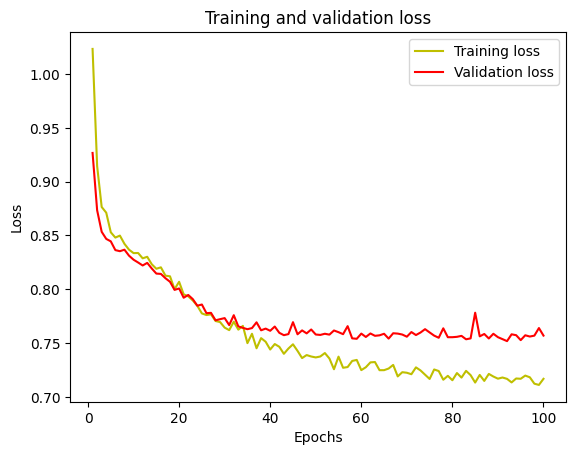

In [48]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

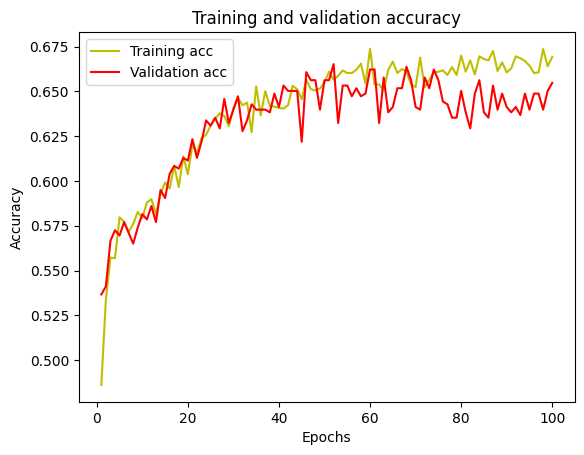

In [49]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [50]:
#Accuracy of the predicted values
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test_class,y_pred_class))
print(confusion_matrix(y_test_class,y_pred_class))

              precision    recall  f1-score   support

           0       0.78      0.79      0.78       281
           1       0.51      0.51      0.51       265
           2       0.67      0.66      0.67       290

    accuracy                           0.66       836
   macro avg       0.65      0.65      0.65       836
weighted avg       0.66      0.66      0.66       836

[[221  47  13]
 [ 49 136  80]
 [ 13  85 192]]
